# 06 — 프롬프트 → 무드 검색 5장 → 1장 선택 → Gemini layout → Rule-based SVG

```
프롬프트 → CLIP 검색 5장 → PICK 선택 → Gemini layout JSON (1회) → Python SVG 렌더 → v3 미리보기
```

- **Gemini**: 객체/위치 추출만 (`gemini-2.5-flash`, API **1회**)
- **SVG**: v3 rule-based Python 렌더러 (API **0회**)
- **셀4**: v3와 동일한 전체 크기 SVG 미리보기 (`IPython.display.SVG`)

실행 순서: **셀1 → 셀2 → 셀3 → 셀4(추출) → 셀5(렌더) → 셀6(미리보기)**

In [1]:
%pip install -r ../requirements-ml.txt -q
%pip install -r ../requirements-gemini.txt -q
%matplotlib inline

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import importlib
import json
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "mood_pipeline").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
OUTPUT_DIR = PROJECT_ROOT / "output" / "floorplans"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

import interior_to_floorplan as itf_module
import mood_pipeline.rule_based_svg as rbs_module
import mood_pipeline.search as search_module
import mood_pipeline.prompt_floorplan as pf_module

for mod in (rbs_module, itf_module, search_module, pf_module):
    importlib.reload(mod)

from mood_pipeline.rule_based_svg import RENDERER_VERSION
from mood_pipeline.search import (
    plot_search_result,
    prepare_prompt_for_search,
    search_mood_with_images,
)
from mood_pipeline.prompt_floorplan import (
    extract_rule_based_layout,
    plot_rule_based_floorplan,
    render_rule_based_floorplan,
    resolve_recommended_image,
)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("RENDERER_VERSION:", RENDERER_VERSION)

c:\Users\jundo\Desktop\창의학기\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_ROOT: C:\Users\jundo\Desktop\창의학기
OUTPUT_DIR: C:\Users\jundo\Desktop\창의학기\output\floorplans
RENDERER_VERSION: 3.7


검색용(EN): Stylish and luxurious room


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 27529.03it/s]


선택 무드: 럭셔리 모던
선택 이미지: C:\Users\jundo\Desktop\창의학기\mood_library\luxury_modern_c07\gallery\8b2343f568a8.jpg


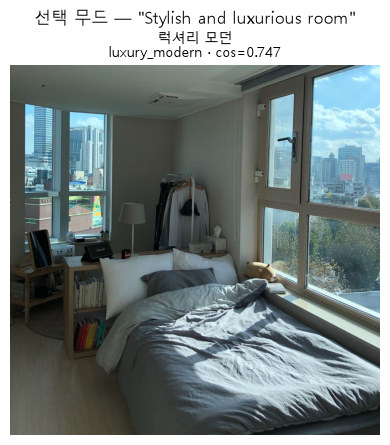

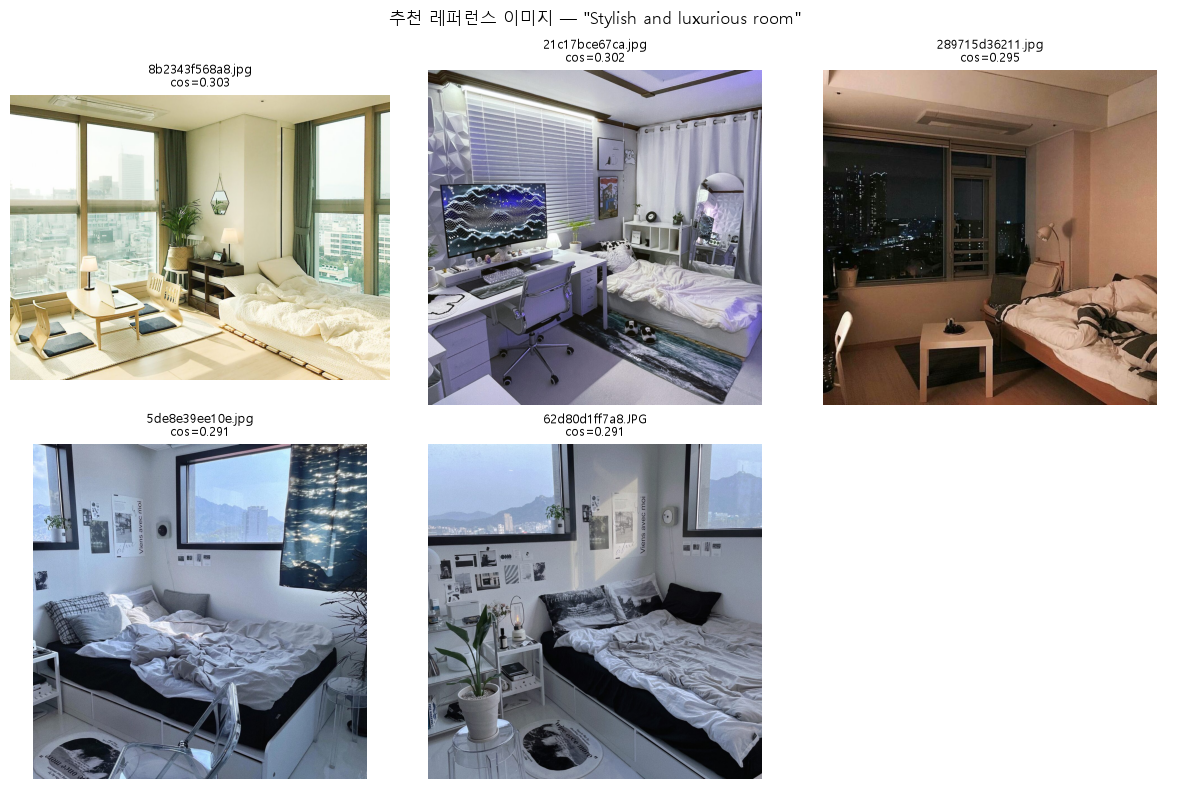

In [3]:
# 1) 프롬프트 → 무드 라이브러리 검색 5장 → 1장 선택
prompt = "세련되고 고급스러운 방"
PICK = 0  # 0~4: gallery 순위 중 선택
TRANSLATE_KO = True

prepared = prepare_prompt_for_search(prompt, translate_ko=TRANSLATE_KO)
print("검색용(EN):", prepared["prompt_en"])

search_result = search_mood_with_images(
    prompt, top_k=5, translate_ko=TRANSLATE_KO, prepared=prepared
)
image_path = resolve_recommended_image(search_result, pick=PICK)

mood = search_result.get("selected_mood") or {}
print("선택 무드:", mood.get("mood_name_ko") or mood.get("mood_id", "?"))
print("선택 이미지:", image_path)
plot_search_result(search_result, prompt=prepared["prompt_en"])

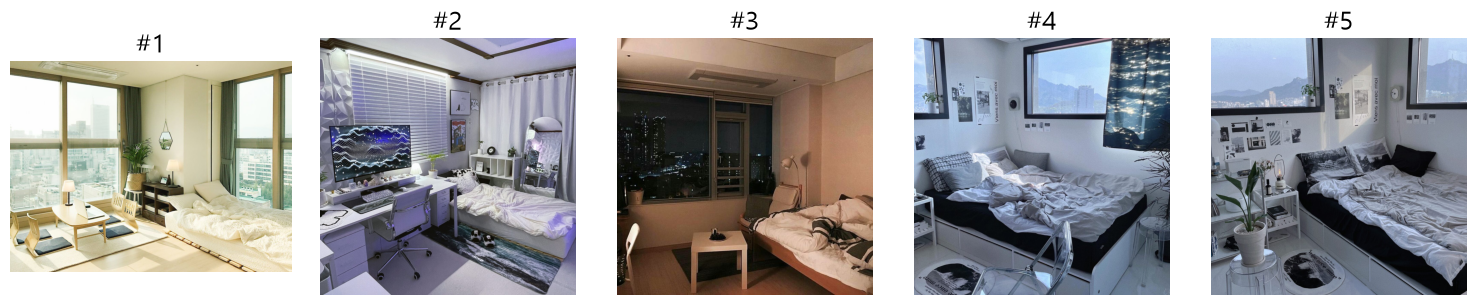

위 썸네일에서 1~5 중 하나를 정해 아래 '추출' 셀의 PICK_IMAGE 값을 바꿔 실행하세요.


In [4]:
# 1.5) 검색된 5장 미리보기 → 원하는 이미지 고르기 (#1~#5)
import matplotlib.pyplot as plt
from PIL import Image
from mood_pipeline.config import MOOD_LIBRARY_DIR

if "search_result" not in globals():
    raise RuntimeError("먼저 검색 셀(셀3)을 실행하세요.")

_images = search_result.get("recommended_images") or []
n = len(_images)
if n == 0:
    raise RuntimeError("추천 이미지가 없습니다. 검색 셀(셀3)을 먼저 실행하세요.")

# 번호 붙은 썸네일로 보여주기
fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
axes = axes if n > 1 else [axes]
for i, (ax, item) in enumerate(zip(axes, _images), start=1):
    ax.imshow(Image.open(MOOD_LIBRARY_DIR / item["path"]).convert("RGB"))
    ax.set_title(f"#{i}", fontsize=18)
    ax.axis("off")
plt.tight_layout()
plt.show()

# 드롭다운으로 고르기 (ipywidgets 가 있을 때). 없으면 아래 추출 셀의 PICK_IMAGE 숫자만 바꾸면 됨.
try:
    import ipywidgets as widgets
    from IPython.display import display

    pick_selector = widgets.Dropdown(
        options=[(f"#{i}", i) for i in range(1, n + 1)],
        value=1,
        description="이미지:",
    )
    display(pick_selector)
    print("↑ 드롭다운에서 고른 뒤 아래 '추출' 셀을 실행하세요.")
except Exception:
    pick_selector = None
    print(f"위 썸네일에서 1~{n} 중 하나를 정해 아래 '추출' 셀의 PICK_IMAGE 값을 바꿔 실행하세요.")

In [5]:
# 2) Gemini — layout JSON 추출 (API 1회)
# 이미지 선택: 위 '고르기' 셀의 드롭다운이 있으면 그 값, 없으면 PICK_IMAGE 사용
PICK_IMAGE = 2  # 드롭다운이 없을 때 쓰는 번호 (1~5)

if "search_result" not in globals():
    raise RuntimeError("먼저 검색 셀(셀3)을 실행하세요.")
_images = search_result.get("recommended_images") or []
if not _images:
    raise RuntimeError("추천 이미지가 없습니다. 검색 셀(셀3)을 먼저 실행하세요.")

_sel = globals().get("pick_selector")
_choice = _sel.value if _sel is not None else PICK_IMAGE
_pick = max(1, min(int(_choice), len(_images)))
image_path = resolve_recommended_image(search_result, pick=_pick - 1)
print(f"선택 이미지 #{_pick} / 총 {len(_images)}장 → {image_path.name}")

FORCE_LAYOUT = True  # True = 캐시 무시하고 재추출 (구 v2 layout 캐시는 SVG 렌더 시 자동 변환)

layout_meta = extract_rule_based_layout(
    image_path, OUTPUT_DIR, skip_existing=not FORCE_LAYOUT
)
print(json.dumps(layout_meta, ensure_ascii=False, indent=2))

layout = json.loads(Path(layout_meta["layout_file"]).read_text(encoding="utf-8"))
print(f"\nobjects: {len(layout.get('objects', []))}개")
print(json.dumps(layout, ensure_ascii=False, indent=2)[:1200])

선택 이미지 #2 / 총 5장 → 21c17bce67ca.jpg
[21c17bce67ca.jpg] Gemini layout 추출 중...
[rule-based layout 추출] API 호출 중… (429/503이면 자동 재시도, Stop 누르지 마세요)
[21c17bce67ca.jpg] 자기교정(refine) 중... (API 1회 추가)
[layout 자기교정] API 호출 중… (429/503이면 자동 재시도, Stop 누르지 마세요)
[21c17bce67ca.jpg] layout 저장 → 21c17bce67ca_layout.json (13 objects, refined=True)
{
  "source": "C:\\Users\\jundo\\Desktop\\창의학기\\mood_library\\luxury_modern_c07\\gallery\\21c17bce67ca.jpg",
  "layout_file": "C:\\Users\\jundo\\Desktop\\창의학기\\output\\floorplans\\21c17bce67ca_layout.json",
  "analysis_model": "gemini-2.5-flash",
  "object_count": 13,
  "renderer": "rule_based_v3",
  "refined": true,
  "skipped": false
}

objects: 13개
{
  "room": {
    "shape": "rectangle",
    "aspect_ratio": 1.3,
    "description": "A modern bedroom with a desk setup on the left and a bed on the right."
  },
  "camera_view": "camera faces the back wall; a large window is on the back wall, and the right wall has curtains.",
  "objects": [
    {
      "type": 

In [6]:
# 3) Python rule-based SVG 렌더 (API 0회) — v3 렌더러
if "layout_meta" not in globals():
    raise RuntimeError("먼저 layout 추출 셀(셀4)을 실행하세요.")

importlib.reload(rbs_module)
importlib.reload(itf_module)
importlib.reload(pf_module)

floorplan_meta = render_rule_based_floorplan(
    image_path,
    OUTPUT_DIR,
    skip_existing=False,  # 항상 최신 렌더러로 재생성 (캐시 사용 안 함)
    title="Rule-based Floor Plan v3",
)
print(json.dumps(floorplan_meta, ensure_ascii=False, indent=2))

svg_path = Path(floorplan_meta["floorplan_svg"])
head = svg_path.read_text(encoding="utf-8")[:200]
print("SVG 저장:", svg_path.resolve())
print("renderer tag:", "renderer-version:3.2" in head)
print("skipped:", floorplan_meta.get("skipped"))

[21c17bce67ca.jpg] rule-based SVG 렌더링 중... (renderer 3.7)
[21c17bce67ca.jpg] SVG 저장 → 21c17bce67ca_rule_based_floorplan.svg
{
  "source": "C:\\Users\\jundo\\Desktop\\창의학기\\mood_library\\luxury_modern_c07\\gallery\\21c17bce67ca.jpg",
  "floorplan_svg": "C:\\Users\\jundo\\Desktop\\창의학기\\output\\floorplans\\21c17bce67ca_rule_based_floorplan.svg",
  "layout_file": "C:\\Users\\jundo\\Desktop\\창의학기\\output\\floorplans\\21c17bce67ca_layout.json",
  "format": "svg",
  "renderer": "python_rule_based_v3",
  "skipped": false
}
SVG 저장: C:\Users\jundo\Desktop\창의학기\output\floorplans\21c17bce67ca_rule_based_floorplan.svg
renderer tag: False
skipped: False


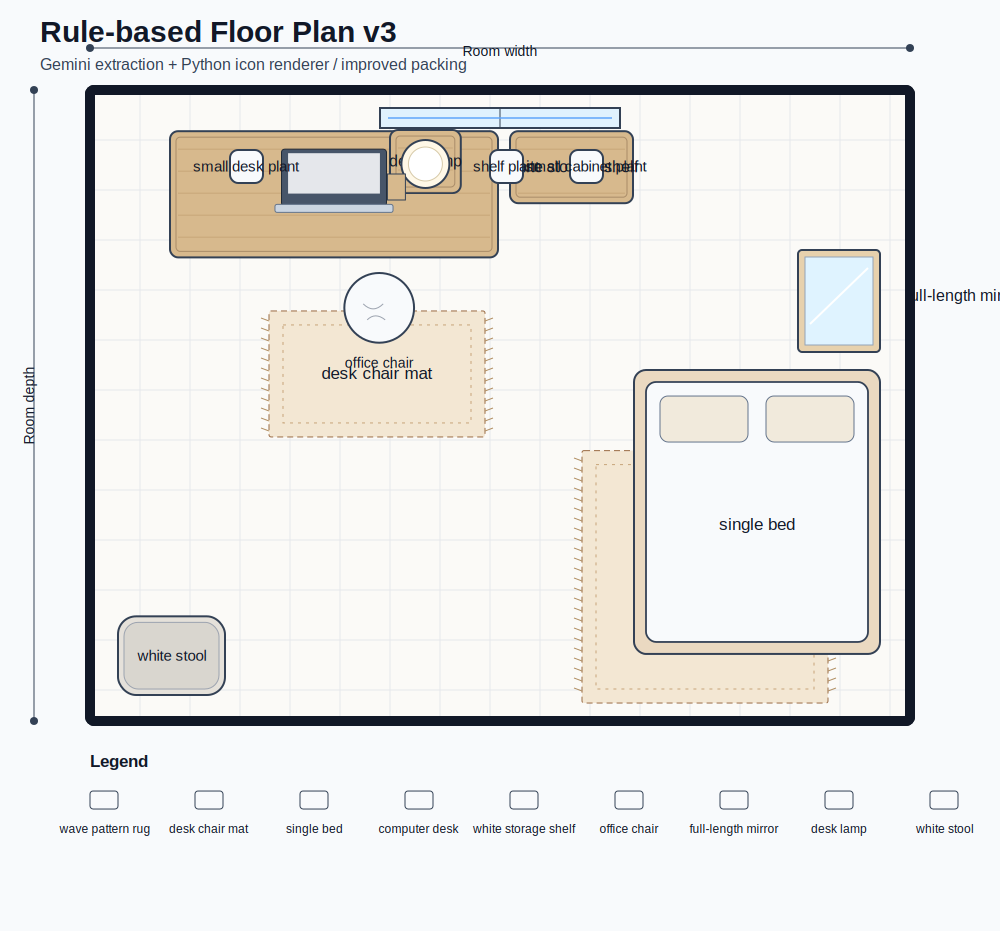

In [7]:
# 4) v3 스타일 SVG 미리보기 (refined_svg_v3 와 동일 — 전체 크기로 표시)
if "svg_path" not in globals():
    svg_path = Path(floorplan_meta["floorplan_svg"])

from IPython.display import SVG, display

display(SVG(filename=str(svg_path)))

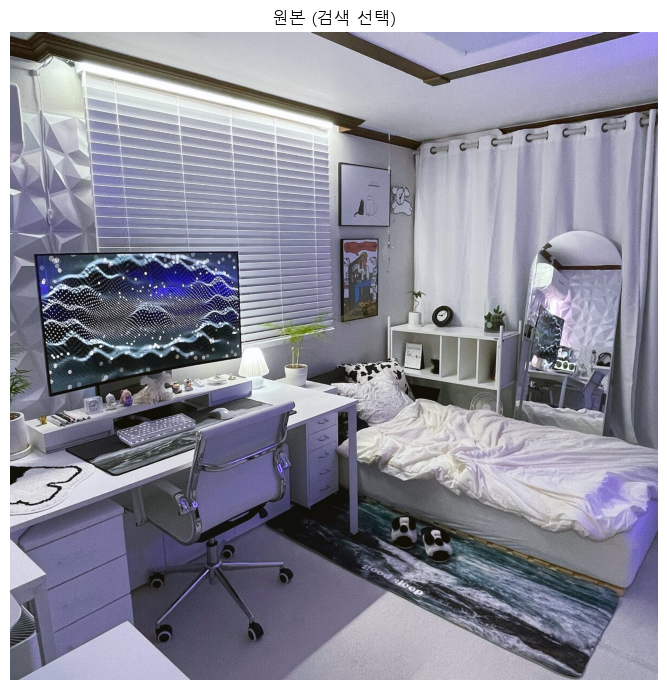

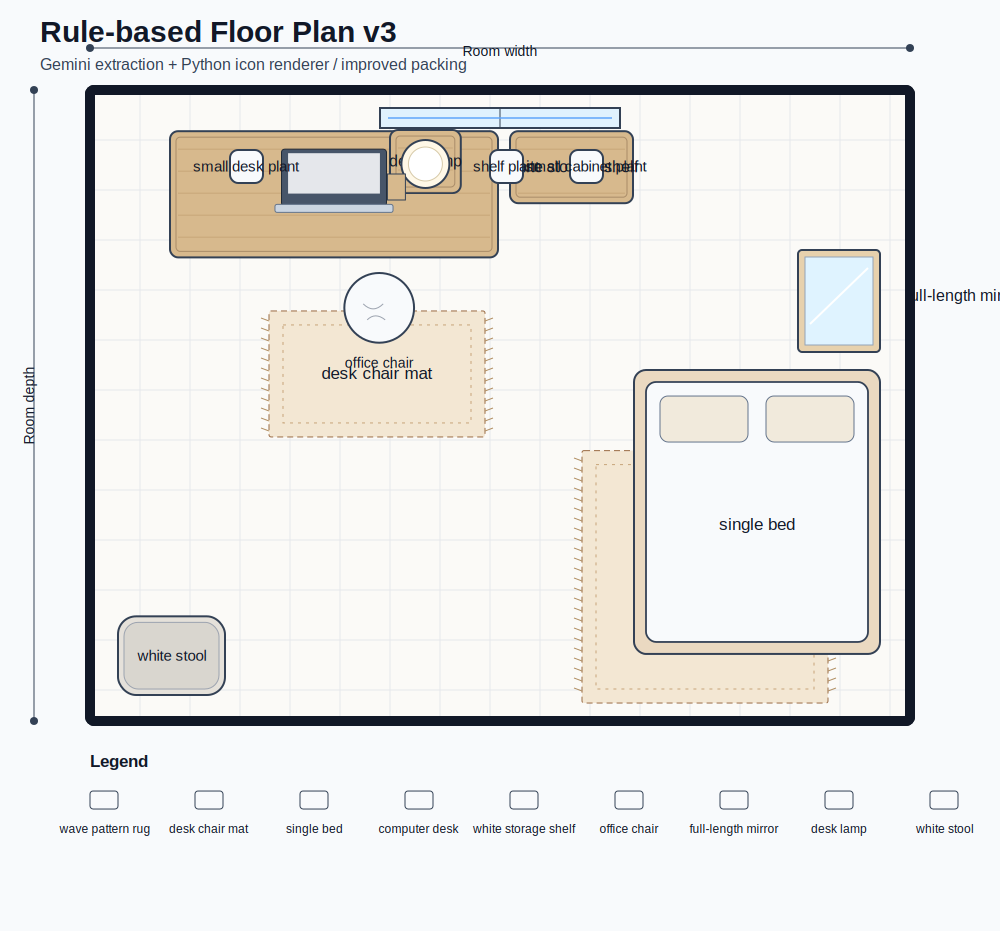

In [8]:
# 5) (선택) 원본 사진 + v3 SVG 나란히
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import SVG, display

fig, ax = plt.subplots(figsize=(9, 7))
ax.imshow(Image.open(image_path).convert("RGB"))
ax.set_title("원본 (검색 선택)")
ax.axis("off")
plt.tight_layout()
plt.show()

display(SVG(filename=str(svg_path)))